In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Read data
df = pd.read_csv("individual model_data 2016_2020 greater manchester.csv")

# Select the features to be used for modeling
features = [
    "sex_of_casualty", "age_band_of_casualty", "under21", "over65",
    "casualty_home_area_type", "casualty_imd_decile", "casualty_depdecile",
    "number_of_vehicles", "number_of_casualties", "road_type",
    "light_conditions", "time", "day_of_week", "weather_effect", "road_wetness"
]

# Copy the data and re-encode the target variable
model_data = df[features + ["slightsevere"]].copy()
model_data["slightsevere"] = model_data["slightsevere"].map({
    "Slight": 0,
    "Severe/Fatal": 1
})

# Remove missing values of the target variable
model_data = model_data.dropna(subset=["slightsevere"])

# Encode categorical variables
categorical_features = model_data.select_dtypes(include="object").columns
for col in categorical_features:
    le = LabelEncoder()
    model_data[col] = le.fit_transform(model_data[col])

# Divide features and objectives
X = model_data.drop(columns=["slightsevere"])
y = model_data["slightsevere"].astype(int)

# Maintain the proportion of categories for training/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Establish Logistic Regression Model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Prediction Probability and Classification
y_pred_prob = logreg.predict_proba(X_test)[:, 1]
y_pred = logreg.predict(X_test)

# Performance Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_prob))

# Output Partial Prediction Results
prediction_sample = pd.DataFrame({
    "True Label": y_test.values[:10],
    "Predicted Probability (Severe/Fatal)": y_pred_prob[:10]
})
print("\nSample Predictions:\n", prediction_sample)


Classification Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88       328
           1       1.00      0.01      0.02        89

    accuracy                           0.79       417
   macro avg       0.89      0.51      0.45       417
weighted avg       0.83      0.79      0.70       417

AUC Score: 0.5413812003288572

Sample Predictions:
    True Label  Predicted Probability (Severe/Fatal)
0           0                              0.158348
1           0                              0.147454
2           0                              0.162689
3           1                              0.222422
4           0                              0.134256
5           0                              0.124864
6           0                              0.133676
7           0                              0.295254
8           0                              0.125188
9           0                              0.212984


D:\anaconda3\envs\py311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Load data
df = pd.read_csv("individual model_data 2016_2020 greater manchester.csv")

# Feature Column
features = [
    "sex_of_casualty", "age_band_of_casualty", "under21", "over65",
    "casualty_home_area_type", "casualty_imd_decile", "casualty_depdecile",
    "number_of_vehicles", "number_of_casualties", "road_type",
    "light_conditions", "time", "day_of_week", "weather_effect", "road_wetness"
]

# Create a copy of the modeling data
model_data = df[features + ["slightsevere"]].copy()

# Encode the target variable
model_data["slightsevere"] = model_data["slightsevere"].map({
    "Slight": 0,
    "Severe/Fatal": 1
})

# Remove Missing Values
model_data = model_data.dropna(subset=["slightsevere"])

# Encode categorical variables
categorical_features = model_data.select_dtypes(include="object").columns
for col in categorical_features:
    le = LabelEncoder()
    model_data[col] = le.fit_transform(model_data[col])

# Separating Features from Objectives
X = model_data.drop(columns=["slightsevere"])
y = model_data["slightsevere"].astype(int)

# Maintain the distribution of categories to divide the training set and the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Store Results
results = {}

# Training and Evaluation of Models
for name, model in [("Random Forest", rf_model), ("XGBoost", xgb_model)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

   # Evaluation Results
    results[name] = {
        "report": classification_report(y_test, y_pred, output_dict=True),
        "auc": roc_auc_score(y_test, y_pred_prob),
        "sample": pd.DataFrame({
            "True Label": y_test.values[:10],
            f"{name} Predicted Probability": y_pred_prob[:10]
        })
    }

# Print Performance Report
for name, result in results.items():
    print(f"\n===== {name} =====")
    print("AUC:", result["auc"])
    print("Classification Report:")
    print(pd.DataFrame(result["report"]).T)
    print("Sample Predictions:")
    print(result["sample"])



===== Random Forest =====
AUC: 0.5559571115374073
Classification Report:
              precision    recall  f1-score     support
0              0.786432  0.954268  0.862259  328.000000
1              0.210526  0.044944  0.074074   89.000000
accuracy       0.760192  0.760192  0.760192    0.760192
macro avg      0.498479  0.499606  0.468167  417.000000
weighted avg   0.663517  0.760192  0.694037  417.000000
Sample Predictions:
   True Label  Random Forest Predicted Probability
0           0                                 0.56
1           0                                 0.03
2           0                                 0.31
3           1                                 0.20
4           0                                 0.08
5           0                                 0.20
6           0                                 0.03
7           0                                 0.10
8           0                                 0.16
9           0                                 0.45

===== XG

D:\anaconda3\envs\py311\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:09:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Load data
df = pd.read_csv("individual model_data 2016_2020 greater manchester.csv")

# 2. Feature Selection
features = [
    "sex_of_casualty", "age_band_of_casualty", "under21", "over65",
    "casualty_home_area_type", "casualty_imd_decile", "casualty_depdecile",
    "number_of_vehicles", "number_of_casualties", "road_type",
    "light_conditions", "time", "day_of_week", "weather_effect", "road_wetness"
]

# 3. Preprocessing
df = df[features + ["slightsevere"]].copy()
df["slightsevere"] = df["slightsevere"].map({"Slight": 0, "Severe/Fatal": 1})
df = df.dropna(subset=["slightsevere"])

# Encode categorical variables
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=["slightsevere"])
y = df["slightsevere"].astype(int)

# 4. Divide the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Define the Model
model_defs = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 6. Model Training and Evaluation
model_scores = []

for name, model in model_defs.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)
    f1 = report["1"]["f1-score"]
    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    model_scores.append({
        "Model": name,
        "AUC": auc,
        "F1 (Severe/Fatal)": f1,
        "Recall (Severe/Fatal)": recall,
        "Precision (Severe/Fatal)": precision
    })

# 7. Comparison Result Table
comparison_df = pd.DataFrame(model_scores)
comparison_df = comparison_df.sort_values(by=["AUC", "F1 (Severe/Fatal)"], ascending=False).reset_index(drop=True)

# Print Result
print("📊 Model performance comparison：\n")
print(comparison_df.to_string(index=False))

# 8. Output the recommendation model
best_model_name = comparison_df.loc[0, "Model"]
print(f"\n🏆 Recommendation model：{best_model_name}")


D:\anaconda3\envs\py311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📊 Model performance comparison：

              Model      AUC  F1 (Severe/Fatal)  Recall (Severe/Fatal)  Precision (Severe/Fatal)
      Random Forest 0.555957           0.074074               0.044944                  0.210526
Logistic Regression 0.541381           0.022222               0.011236                  1.000000
            XGBoost 0.489261           0.144000               0.101124                  0.250000

🏆 Recommendation model：Random Forest


D:\anaconda3\envs\py311\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:09:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [2]:
import pandas as pd
import folium
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from branca.colormap import LinearColormap

# 1. Load data
df = pd.read_csv("individual model_data 2016_2020 greater manchester.csv")

required_columns = [
    "sex_of_casualty", "age_band_of_casualty", "under21", "over65",
    "casualty_home_area_type", "casualty_imd_decile", "casualty_depdecile",
    "number_of_vehicles", "number_of_casualties", "road_type",
    "light_conditions", "time", "day_of_week", "weather_effect", "road_wetness",
    "longitude", "latitude", "lsoa_of_accident_location",
    "local_authority_district", "slightsevere"
]
df = df[required_columns].copy()
df["slightsevere"] = df["slightsevere"].map({"Slight": 0, "Severe/Fatal": 1})
df = df.dropna(subset=["slightsevere", "longitude", "latitude", "lsoa_of_accident_location"])

# Encode non-displayed fields
for col in df.select_dtypes(include="object").columns:
    if col not in ["lsoa_of_accident_location", "local_authority_district"]:
        df[col] = LabelEncoder().fit_transform(df[col])

# Feature + Model
features = [
    "sex_of_casualty", "age_band_of_casualty", "under21", "over65",
    "casualty_home_area_type", "casualty_imd_decile", "casualty_depdecile",
    "number_of_vehicles", "number_of_casualties", "road_type",
    "light_conditions", "time", "day_of_week", "weather_effect", "road_wetness"
]
X = df[features]
y = df["slightsevere"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
df["pred_prob_severe"] = rf.predict_proba(X)[:, 1]

# Create a color gradient mapping (green -> yellow -> orange -> red)
colormap = LinearColormap(
    colors=["#2DC937", "#E7B416", "#FF8000", "#CC3232", "#990000"],
    vmin=df["pred_prob_severe"].min(),
    vmax=df["pred_prob_severe"].max(),
    caption="Predicted Bicycle Accident Probability"
)

# Create Map
m = folium.Map(location=[df["latitude"].mean(), df["longitude"].mean()], zoom_start=11)

# Add points and tooltips
for _, row in df.iterrows():
    hover_text = f"""
    LSOA Code: {row['lsoa_of_accident_location']}<br>
    Area Name: {row['local_authority_district']}<br>
    Pred. Prob: {row['pred_prob_severe']:.3f}
    """
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,
        fill=True,
        fill_opacity=0.7,
        color=None,
        fill_color=colormap(row["pred_prob_severe"]),
        tooltip=folium.Tooltip(hover_text)
    ).add_to(m)

# Add legend to the map
colormap.add_to(m)

# save
m.save("severe_accident_hover_map_with_legend.html")
print("✅ 地图已保存为 severe_accident_hover_map_with_legend.html")


from IPython.display import IFrame

IFrame(src='severe_accident_hover_map_with_legend.html', width=700, height=600)


✅ 地图已保存为 severe_accident_hover_map_with_legend.html


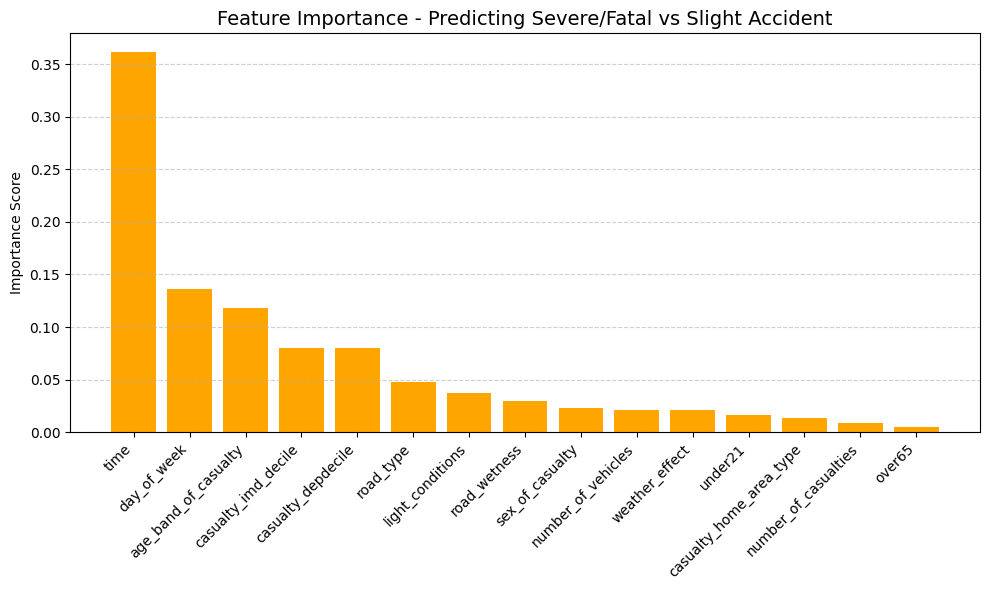

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure that you have trained the random forest model `rf` and have defined the `features` variable # rf = RandomForestClassifier(...)
# rf.fit(...)
# features = [...]

# Obtain Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = np.array(features)[indices]
sorted_importances = importances[indices]

# Visualization
plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Predicting Severe/Fatal vs Slight Accident", fontsize=14)
plt.bar(range(len(features)), sorted_importances, align="center", color="orange")
plt.xticks(range(len(features)), feature_names, rotation=45, ha="right")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()
